In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from matplotlib.path import Path
from matplotlib.patches import PathPatch
from matplotlib.backend_bases import MouseButton

In [2]:
def left_mouse_clicked(event):
    if event.button is MouseButton.LEFT:
        print('Mouse Clicked!')
        print('\nMouse X Data: ', event.xdata)
        print('Mouse Y Data: ', event.ydata)
        print('\nMouse X Coordinate: ', event.x)
        print('Mouse Y Coordinate: ', event.y)

In [3]:
def main():
    img = np.asarray(Image.open('knight.png'))
#     control_points_1 = [(0, 0), (0.5, 0.5), (0, 1)]
#     control_points_2 = [(0, 1), (0.5, 0), (1, 1)]
#     control_points_3 = [(1, 0), (0.5, 0.5), (1, 1)]
    h, w, c = img.shape
    print(f'Height: {h}')
    print(f'Width: {w}')
    
    control_points_1 = [(0, 0), (w/2, h/2),(0, h)]
    control_points_2 = [(0, h), (w/2, 0), (w, h)]
    control_points_3 = [(w, 0), (w/2, h/2), (w, h)]
    print(f'CP1: {control_points_1}')
    print(f'CP2: {control_points_2}')
    print(f'CP3: {control_points_3}')
    
#     Used for coloring an overlay over image
#     pixel = (110, 57, 85, 0.63)
#     r, g, b, a = pixel
#     r = r/255.0
#     g = g/255.0
#     b = b/255.0
#     a = a/2
#     pixel = (r,g,b,a)
    figure, axes = plt.subplots()
    bezier_curve_1 = PathPatch(Path(control_points_1, [Path.MOVETO, Path.CURVE3, Path.CURVE3]), transform=axes.transData)
    bezier_curve_2 = PathPatch(Path(control_points_2, [Path.MOVETO, Path.CURVE3, Path.CURVE3]), transform=axes.transData)
    bezier_curve_3 = PathPatch(Path(control_points_3, [Path.MOVETO, Path.CURVE3, Path.CURVE3]), transform=axes.transData)

#     axes.add_patch(bezier_curve_1)
#     axes.add_patch(bezier_curve_3)
#     axes.add_patch(bezier_curve_2)

    plt.connect('button_press_event', left_mouse_clicked)
    im = axes.imshow(img)
#    patch = patches.Circle((260, 200), radius=200, transform=axes.transData)
#    im.set_clip_path(patch)
    im.set_clip_path(bezier_curve_1)
    im.set_clip_path(bezier_curve_2)
    im.set_clip_path(bezier_curve_3)
    plt.show()

Height: 1024
Width: 1536
CP1: [(0, 0), (768.0, 512.0), (0, 1024)]
CP2: [(0, 1024), (768.0, 0), (1536, 1024)]
CP3: [(1536, 0), (768.0, 512.0), (1536, 1024)]


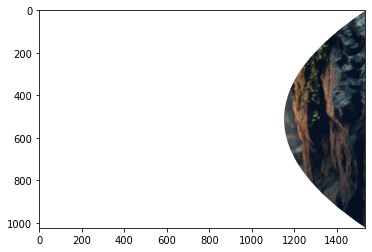

In [4]:
main()